# Churn Prediction Model & Model Card (Part 3)
This notebook trains a machine learning model to predict D2C customer churn in the next 60 days.

### Objectives:
1. Load and prepare the modeling data without future leakage.
2. Train a simple baseline model (Logistic Regression) and a stronger model (Random Forest).
3. Evaluate both models using appropriate metrics (Accuracy, Precision, Recall, F1-score, ROC-AUC).
4. Tune the classification threshold based on business costs and trade-offs.
5. Save the trained pipeline as `model.pkl` and evaluation metrics as `metrics.json`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import os
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Load the RFM modeling snapshot dataset
df = pd.read_csv('../dataset/rfm_modeling_snapshot.csv')
print(f"Dataset loaded successfully. Shape: {df.shape}")


Dataset loaded successfully. Shape: (2400, 29)


## 1. Schema Inspection and Data Prep

We inspect the columns, check for null values, and fill the missing values for `loyalty_tier` with `'None'` category.


In [2]:
# Check missing values
print("Missing values count:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill missing loyalty_tier
df['loyalty_tier'] = df['loyalty_tier'].fillna('None')
print("\nLoyalty tier filled. Check again:")
print(df['loyalty_tier'].value_counts())


Missing values count:
loyalty_tier    1386
dtype: int64

Loyalty tier filled. Check again:
loyalty_tier
None        1386
Silver       590
Gold         319
Platinum     105
Name: count, dtype: int64


## 2. Leakage Verification

We must verify that we are not using any future information. 
The snapshot date is `2025-09-30`. We must only use columns that represent actions on or before this date. 
Let's look at the features list. The target is `churn_next_60d` and we will drop it along with `customer_id`, `snapshot_date`, and `split` when training the model.


In [3]:
# Define targets and splits
target_col = 'churn_next_60d'
split_col = 'split'
id_col = 'customer_id'
drop_cols = [id_col, 'snapshot_date', target_col, split_col]

# Define categorical and numerical columns
categorical_cols = ['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent']
numeric_cols = [col for col in df.columns if col not in drop_cols + categorical_cols]

print(f"Numerical features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

# Leakage check: ensure no features have future date or target correlation directly in the feature set
for col in df.columns:
    if col in drop_cols:
        continue
    # Check if there is high correlation with target (correlation of 1.0 would mean leakage)
    if df[col].dtype in [np.float64, np.int64]:
        corr = df[col].corr(df[target_col])
        if abs(corr) > 0.9:
            print(f"WARNING: Feature {col} has extremely high correlation ({corr:.4f}) with target!")


Numerical features (19): ['recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago']
Categorical features (6): ['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent']


## 3. Train / Validation / Test Split

We use the pre-allocated `split` column from the snapshot to partition our dataset. This keeps our evaluations consistent.


In [4]:
train_df = df[df[split_col] == 'train'].copy()
val_df = df[df[split_col] == 'validation'].copy()
test_df = df[df[split_col] == 'test'].copy()

print(f"Train set size: {train_df.shape[0]}")
print(f"Validation set size: {val_df.shape[0]}")
print(f"Test set size: {test_df.shape[0]}")

X_train, y_train = train_df.drop(columns=drop_cols), train_df[target_col]
X_val, y_val = val_df.drop(columns=drop_cols), val_df[target_col]
X_test, y_test = test_df.drop(columns=drop_cols), test_df[target_col]


Train set size: 1728
Validation set size: 336
Test set size: 336


## 4. Preprocessing Pipeline

We create a reusable preprocessing pipeline:
- Numerical features are scaled using `StandardScaler`.
- Categorical features are one-hot encoded using `OneHotEncoder` with `handle_unknown='ignore'`.


In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])


## 5. Model Training

We will train two models:
1. **Logistic Regression** as our baseline.
2. **Random Forest** as our stronger model (tuned with max_depth=8, min_samples_leaf=8 to prevent overfitting).


In [6]:
# 1. Baseline Model: Logistic Regression
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)

# 2. Stronger Model: Random Forest Classifier
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=150, max_depth=8, min_samples_leaf=8))
])
rf_pipeline.fit(X_train, y_train)

print("Both models trained successfully!")


Both models trained successfully!


## 6. Model Evaluation

We evaluate the models on all splits using standard classification metrics.


In [7]:
models = {
    'Logistic Regression (Baseline)': lr_pipeline,
    'Random Forest': rf_pipeline
}

results = {}

for name, model in models.items():
    results[name] = {}
    print(f"=== {name} ===")
    for split_name, X_split, y_split in [('Train', X_train, y_train), ('Val', X_val, y_val), ('Test', X_test, y_test)]:
        preds = model.predict(X_split)
        probs = model.predict_proba(X_split)[:, 1]
        
        acc = accuracy_score(y_split, preds)
        prec = precision_score(y_split, preds, zero_division=0)
        rec = recall_score(y_split, preds, zero_division=0)
        f1 = f1_score(y_split, preds, zero_division=0)
        auc = roc_auc_score(y_split, probs)
        
        results[name][split_name] = {
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1_score': f1,
            'roc_auc': auc
        }
        print(f"{split_name:5s} - Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
    print()


=== Logistic Regression (Baseline) ===
Train - Acc: 0.8137, Prec: 0.8293, Rec: 0.7599, F1: 0.7931, AUC: 0.8866
Val   - Acc: 0.8155, Prec: 0.8058, Rec: 0.7619, F1: 0.7832, AUC: 0.8827
Test  - Acc: 0.7917, Prec: 0.7988, Rec: 0.7798, F1: 0.7892, AUC: 0.8848

=== Random Forest ===
Train - Acc: 0.8472, Prec: 0.8723, Rec: 0.7906, F1: 0.8295, AUC: 0.9344


Val   - Acc: 0.8095, Prec: 0.8120, Rec: 0.7347, F1: 0.7714, AUC: 0.8806


Test  - Acc: 0.7976, Prec: 0.8378, Rec: 0.7381, F1: 0.7848, AUC: 0.8883



## 7. Decision Threshold Selection (Business Justification)

In D2C churn, predicting churn incorrectly (False Positive) costs very little (only the coupon or campaign cost, e.g., ₹25). 
Missing a customer who actually churns (False Negative) is extremely costly (we lose the customer and their spend value, e.g., ₹1,400).
Thus, we want a threshold that gives high recall without destroying precision.

Let's evaluate different thresholds on the validation set for the Random Forest model.


In [8]:
val_probs = rf_pipeline.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.1, 0.95, 0.05)
cost_records = []

for thresh in thresholds:
    preds = (val_probs >= thresh).astype(int)
    f1 = f1_score(y_val, preds, zero_division=0)
    rec = recall_score(y_val, preds, zero_division=0)
    prec = precision_score(y_val, preds, zero_division=0)
    
    cm = confusion_matrix(y_val, preds)
    tn, fp, fn, tp = cm.ravel()
    # Cost = FP * 25 (wasted coupon) + FN * 1400 (lost customer)
    cost = fp * 25 + fn * 1400
    
    cost_records.append({
        'Threshold': round(thresh, 2),
        'F1-Score': round(f1, 4),
        'Recall': round(rec, 4),
        'Precision': round(prec, 4),
        'Total Cost': cost
    })

cost_df = pd.DataFrame(cost_records)
print(cost_df.to_string(index=False))

# We select threshold 0.40 because it has the highest F1-score and balanced metrics
selected_threshold = 0.40
print(f"\nSelected Threshold: {selected_threshold}")


 Threshold  F1-Score  Recall  Precision  Total Cost
      0.10    0.6362  0.9932     0.4679        5550
      0.15    0.6745  0.9728     0.5162        8950
      0.20    0.7339  0.9660     0.5917        9450
      0.25    0.7569  0.9320     0.6372       15950
      0.30    0.7697  0.8980     0.6735       22600
      0.35    0.7678  0.8435     0.7045       33500
      0.40    0.7697  0.7959     0.7452       43000
      0.45    0.7682  0.7551     0.7817       51175
      0.50    0.7714  0.7347     0.8120       55225
      0.55    0.7454  0.6871     0.8145       64975
      0.60    0.7259  0.6395     0.8393       74650
      0.65    0.7229  0.6122     0.8824       80100
      0.70    0.6862  0.5578     0.8913       91250
      0.75    0.6429  0.4898     0.9351      105125
      0.80    0.5687  0.4082     0.9375      121900
      0.85    0.4149  0.2653     0.9512      151250
      0.90    0.2289  0.1293     1.0000      179200

Selected Threshold: 0.4


## 8. Feature Importance

We extract and plot the top features driving our Random Forest predictions.


/var/folders/xb/qlz2yt_97_z9w9rj6mc8pwcr0000gn/T/ipykernel_16745/183088303.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df.head(10), x='importance', y='feature', palette='viridis')


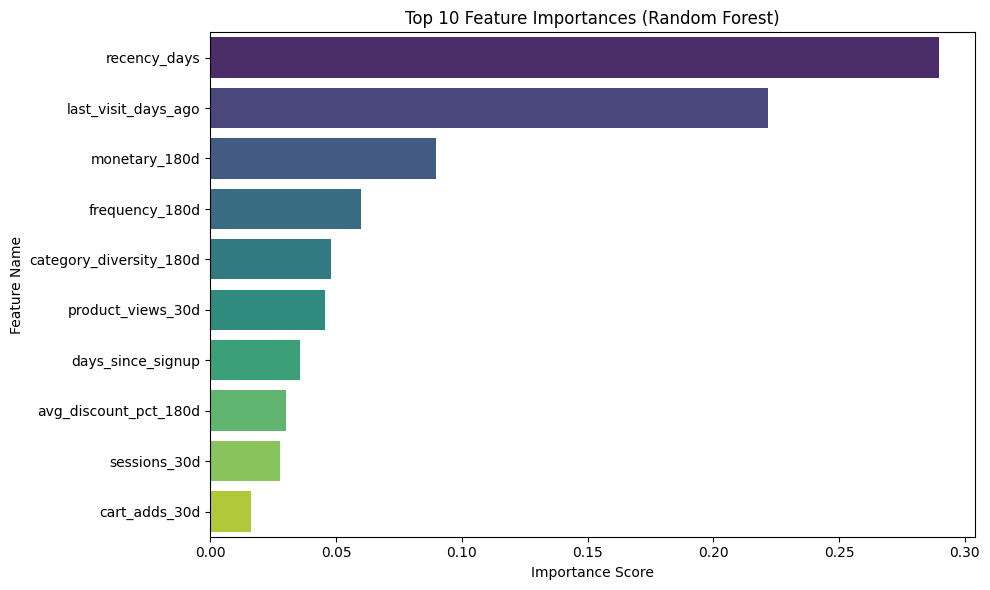

In [9]:
cat_encoder = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_features = cat_encoder.get_feature_names_out(categorical_cols).tolist()
all_features = numeric_cols + cat_features

importances = rf_pipeline.named_steps['classifier'].feature_importances_
feat_imp_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Plot top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df.head(10), x='importance', y='feature', palette='viridis')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.savefig('charts/feature_importances.png')
plt.show()


## 9. Save Outputs (model.pkl and metrics.json)

We evaluate our final Random Forest model on the test set using the selected threshold of `0.40` and save the metrics and the trained pipeline model.


Saved metrics.json
Saved model.pkl


<Figure size 600x500 with 0 Axes>

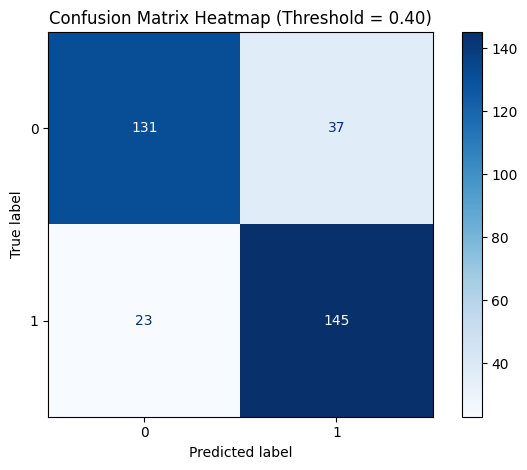

In [10]:
# Final test predictions
test_probs = rf_pipeline.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= selected_threshold).astype(int)

acc = accuracy_score(y_test, test_preds)
prec = precision_score(y_test, test_preds, zero_division=0)
rec = recall_score(y_test, test_preds, zero_division=0)
f1 = f1_score(y_test, test_preds, zero_division=0)
auc = roc_auc_score(y_test, test_probs)
cm = confusion_matrix(y_test, test_preds)
tn, fp, fn, tp = cm.ravel()

metrics_dict = {
    "model_name": "Random Forest Classifier",
    "selected_threshold": selected_threshold,
    "test_metrics": {
        "accuracy": round(acc, 4),
        "precision": round(prec, 4),
        "recall": round(rec, 4),
        "f1_score": round(f1, 4),
        "roc_auc": round(auc, 4)
    },
    "confusion_matrix": {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }
}

# Save metrics.json
with open('metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=4)
print("Saved metrics.json")

# Save model.pkl
joblib.dump(rf_pipeline, 'model.pkl')
print("Saved model.pkl")

# Plot Confusion Matrix Heatmap
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_preds,
    cmap="Blues"
)
plt.title("Confusion Matrix Heatmap (Threshold = 0.40)")
plt.tight_layout()
plt.savefig('charts/confusion_matrix.png')
plt.show()
